In [1]:

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"]= "0"


In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from typing import Optional
import numpy

def _to_numpy_image(img) -> "numpy.ndarray":
    try:
        import numpy as np
    except ImportError:
        raise ImportError("需要 numpy 来显示原图")
    if isinstance(img, torch.Tensor):
        x = img.detach().cpu()
        if x.dim() == 3 and x.shape[0] in (1, 3):  # CHW -> HWC
            x = x.permute(1, 2, 0)
        x = x.float().clamp(0.0, 1.0).numpy()
        return x
    elif hasattr(img, "__array__"):
        x = img
        x = x.astype("float32") if hasattr(x, "astype") else x
        return x
    else:
        raise TypeError("orig_image 需要是 Tensor 或 numpy 数组")

# 示例：
# sim = visualize_dec_in_self_similarity(dec_in_feats, row=5, col=7, orig_image=dec_in_img, mask_self=True)



In [3]:
import sys
import torch
from pathlib import Path

# 添加项目路径
project_root = Path.cwd()
sys.path.append(str(project_root))

from latent_action_model.genie.dataset import LightningOpenX


2026-01-08 11:05:59.649694: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-08 11:05:59.706991: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-08 11:05:59.707053: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-08 11:05:59.708573: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-08 11:05:59.716363: I tensorflow/core/platform/cpu_feature_guar

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from typing import Optional


def visualize_self_similarity(
    dec_in_feats,
    index: Optional[int] = None,
    row: Optional[int] = None,
    col: Optional[int] = None,
    *,
    orig_image: Optional[object] = None,
    mask_self: bool = False,
    cmap: str = "coolwarm",
    vmin: Optional[float] = -1.0,
    vmax: Optional[float] = 1.0,
    title: Optional[str] = None,
    show_colorbar: bool = True,
    orig_title: str = "Original",
) -> "torch.Tensor":
    if dec_in_feats.dim() != 3:
        raise ValueError("dec_in_feats 需要是 [dim, H, W] 张量")

    dim, H, W = dec_in_feats.shape

    if index is not None:
        row = int(index) // W
        col = int(index) % W
    if row is None or col is None:
        raise ValueError("需要提供 index 或 (row, col) 其中之一")
    if not (0 <= row < H and 0 <= col < W):
        raise ValueError(f"(row, col)=({row}, {col}) 超出范围 H={H}, W={W}")

    feats = F.normalize(dec_in_feats, p=2, dim=0)
    anchor = feats[:, row, col]
    sim_map = (feats * anchor.view(dim, 1, 1)).sum(dim=0).detach().cpu()

    if mask_self:
        sim_map[row, col] = float("nan")

    if orig_image is None:
        plt.figure(figsize=(5, 5))
        ax = plt.gca()
        im = ax.imshow(sim_map.numpy(), cmap=cmap, vmin=vmin, vmax=vmax)
        ax.scatter([col], [row], s=60, facecolors="none", edgecolors="black", linewidths=1.5)
        ax.set_xlabel("w_patches")
        ax.set_ylabel("h_patches")
        if title is None:
            title = f"Intra dec_in similarity — (row={row}, col={col}, idx={row * W + col})"
        ax.set_title(title)
        if show_colorbar:
            plt.colorbar(im, ax=ax)
    else:
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        # 左：原图（坐标映射到 patch 网格坐标）
        img_np = _to_numpy_image(orig_image)
        axes[0].imshow(img_np, extent=[0, W, H, 0])
        axes[0].scatter([col + 0.5], [row + 0.5], s=60, facecolors="none", edgecolors="red", linewidths=1.5)
        axes[0].set_title(orig_title)
        axes[0].set_xlim(0, W)
        axes[0].set_ylim(H, 0)
        axes[0].set_xticks([])
        axes[0].set_yticks([])
        # 右：热图
        im = axes[1].imshow(sim_map.numpy(), cmap=cmap, vmin=vmin, vmax=vmax)
        axes[1].scatter([col], [row], s=60, facecolors="none", edgecolors="red", linewidths=1.5)
        axes[1].set_xlabel("w_patches")
        axes[1].set_ylabel("h_patches")
        if title is None:
            title = f"Intra dec_in similarity — (row={row}, col={col}, idx={row * W + col})"
        axes[1].set_title(title)
        if show_colorbar:
            fig.colorbar(im, ax=axes[1])
    plt.tight_layout()
    plt.show()
    plt.close()

    return sim_map


def visualize_cross_image_similarity(
    src_feats,
    dst_feats,
    src_index: Optional[int] = None,
    src_row: Optional[int] = None,
    src_col: Optional[int] = None,
    *,
    src_image: Optional[object] = None,
    dst_image: Optional[object] = None,
    cmap: str = "coolwarm",
    vmin: Optional[float] = -1.0,
    vmax: Optional[float] = 1.0,
    title: Optional[str] = None,
    show_colorbar: bool = False,
    src_title: str = "Source",
    dst_title: str = "Target",
    overlay_on_dst: bool = False,
) -> "torch.Tensor":
    if src_feats.dim() != 3 or dst_feats.dim() != 3:
        raise ValueError("src_feats 和 dst_feats 都需要是 [dim, H, W] 张量")

    dim_s, Hs, Ws = src_feats.shape
    dim_t, Ht, Wt = dst_feats.shape
    if dim_s != dim_t:
        raise ValueError(f"特征维不一致: src dim={dim_s}, dst dim={dim_t}")

    if src_index is not None:
        src_row = int(src_index) // Ws
        src_col = int(src_index) % Ws
    if src_row is None or src_col is None:
        raise ValueError("需要提供 src_index 或 (src_row, src_col) 其中之一")
    if not (0 <= src_row < Hs and 0 <= src_col < Ws):
        raise ValueError(f"(src_row, src_col)=({src_row}, {src_col}) 超出范围 Hs={Hs}, Ws={Ws}")

    src_feats_n = F.normalize(src_feats, p=2, dim=0)
    dst_feats_n = F.normalize(dst_feats, p=2, dim=0)

    anchor = src_feats_n[:, src_row, src_col]
    sim_map_tgt = (dst_feats_n * anchor.view(dim_s, 1, 1)).sum(dim=0).detach().cpu()

    if overlay_on_dst and (dst_image is not None):
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        # 源原图（映射到 patch 网格坐标并标点）
        if src_image is not None:
            axes[0].imshow(_to_numpy_image(src_image), extent=[0, Ws, Hs, 0])
            axes[0].scatter([src_col + 0.5], [src_row + 0.5], s=60, facecolors="none", edgecolors="red", linewidths=1.5)
            axes[0].set_xlim(0, Ws)
            axes[0].set_ylim(Hs, 0)
            axes[0].set_xticks([])
            axes[0].set_yticks([])
        axes[0].set_title(src_title)
        # 目标原图 + 热图
        axes[1].imshow(_to_numpy_image(dst_image))
        im = axes[1].imshow(sim_map_tgt.numpy(), cmap=cmap, vmin=vmin, vmax=vmax, alpha=0.8)
        if title is None:
            title = f"Cross similarity — src(row={src_row}, col={src_col}) -> target"
        axes[1].set_title(title)
        axes[1].set_xlabel("w_patches")
        axes[1].set_ylabel("h_patches")
        if show_colorbar:
            fig.colorbar(im, ax=axes[1])
    else:
        num_imgs = int(src_image is not None) + int(dst_image is not None)
        cols = max(1, num_imgs + 1)
        fig, axes = plt.subplots(1, cols, figsize=(5 * cols, 5))
        ax_list = axes.flatten().tolist() if isinstance(axes, np.ndarray) else ([axes] if not isinstance(axes, (list, tuple)) else list(axes))
        idx = 0
        if src_image is not None:
            ax_list[idx].imshow(_to_numpy_image(src_image), extent=[0, Ws, Hs, 0])
            ax_list[idx].scatter([src_col + 0.5], [src_row + 0.5], s=60, facecolors="none", edgecolors="red", linewidths=1.5)
            ax_list[idx].set_xlim(0, Ws)
            ax_list[idx].set_ylim(Hs, 0)
            ax_list[idx].set_xticks([])
            ax_list[idx].set_yticks([])
            ax_list[idx].set_title(src_title)
            idx += 1
        if dst_image is not None:
            ax_list[idx].imshow(_to_numpy_image(dst_image))
            ax_list[idx].set_title(dst_title)
            ax_list[idx].axis('off')
            idx += 1
        im = ax_list[idx].imshow(sim_map_tgt.numpy(), cmap=cmap, vmin=vmin, vmax=vmax)
        if title is None:
            title = f"Cross similarity — src(row={src_row}, col={src_col}) -> target"
        ax_list[idx].set_title(title)
        ax_list[idx].set_xlabel("w_patches")
        ax_list[idx].set_ylabel("h_patches")
        if show_colorbar:
            fig.colorbar(im, ax=ax_list[idx])
    plt.tight_layout()
    plt.show()
    plt.close()

    return sim_map_tgt



In [5]:
# 创建数据模块
data_module = LightningOpenX(
    data_root="/mnt/project_rlinf/jlchen/datasets",
    data_mix="libero_90",
    batch_size=128,
    resolution=256,
    episodic=False,
    shuffle_buffer_size=10240,
    image_aug=False,
    training_phase="lam_2f"  #lam_2f
)

# 设置数据集
data_module.setup("fit")

# 获取数据加载器
train_loader = data_module.train_dataloader()
print(f"✅ 数据加载器创建成功")


01/08 [11:06:19] INFO     | >> Load dataset info from                                           ]8;id=234053;file:///usr/local/miniconda3/envs/vla/lib/python3.10/site-packages/tensorflow_datasets/core/dataset_info.py\dataset_info.py]8;;\:]8;id=146316;file:///usr/local/miniconda3/envs/vla/lib/python3.10/site-packages/tensorflow_datasets/core/dataset_info.py#599\599]8;;\
                          /mnt/project_rlinf/jlchen/datasets/libero_90_rlds/1.0.0                                  

01/08 [11:06:20] INFO     | >> Constructing tf.data.Dataset liber_o90 for split all, from      ]8;id=91161;file:///usr/local/miniconda3/envs/vla/lib/python3.10/site-packages/tensorflow_datasets/core/logging/logging_logger.py\logging_logger.py]8;;\:]8;id=619176;file:///usr/local/miniconda3/envs/vla/lib/python3.10/site-packages/tensorflow_datasets/core/logging/logging_logger.py#49\49]8;;\
                          /mnt/project_rlinf/jlchen/datasets/libero_90_rlds/1.0.0                                  

2026-01-08 11:06:20.126238: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization


                 INFO     | >> [*] Loading existing dataset statistics from                       ]8;id=529903;file:///mnt/project_rlinf/jlchen/code/UniVLA/prismatic/vla/datasets/rlds/utils/data_utils.py\data_utils.py]8;;\:]8;id=631262;file:///mnt/project_rlinf/jlchen/code/UniVLA/prismatic/vla/datasets/rlds/utils/data_utils.py#208\208]8;;\
                          /mnt/project_rlinf/jlchen/datasets/libero_90_rlds/1.0.0/dataset_statist                  
                          ics_e782e2bd6447691f1f880e1d3d69ed74f15e06cd0f0ea6d25fb80c1bff7e6353.js                  
                          on.                                                                                      

                 INFO     | >> Constructing tf.data.Dataset liber_o90 for split train[:95%],   ]8;id=681453;file:///usr/local/miniconda3/envs/vla/lib/python3.10/site-packages/tensorflow_datasets/core/logging/logging_logger.py\logging_logger.py]8;;\:]8;id=735392;file:///usr/local/miniconda3/envs/vla/lib/python3.10/site-packages/tensorflow_datasets/core/logging/logging_logger.py#49\49]8;;\
                          from /mnt/project_rlinf/jlchen/datasets/libero_90_rlds/1.0.0                             

...

                 INFO     | >> Load dataset info from                                           ]8;id=970342;file:///usr/local/miniconda3/envs/vla/lib/python3.10/site-packages/tensorflow_datasets/core/dataset_info.py\dataset_info.py]8;;\:]8;id=671088;file:///usr/local/miniconda3/envs/vla/lib/python3.10/site-packages/tensorflow_datasets/core/dataset_info.py#599\599]8;;\
                          /mnt/project_rlinf/jlchen/datasets/libero_90_rlds/1.0.0                                  

                 INFO     | >> Constructing tf.data.Dataset liber_o90 for split train[95%:],   ]8;id=340035;file:///usr/local/miniconda3/envs/vla/lib/python3.10/site-packages/tensorflow_datasets/core/logging/logging_logger.py\logging_logger.py]8;;\:]8;id=883794;file:///usr/local/miniconda3/envs/vla/lib/python3.10/site-packages/tensorflow_datasets/core/logging/logging_logger.py#49\49]8;;\
                          from /mnt/project_rlinf/jlchen/datasets/libero_90_rlds/1.0.0                             

2026-01-08 11:06:23.956525: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization


01/08 [11:06:24] INFO     | >> [*] Applying frame transforms on dataset...                           ]8;id=861722;file:///mnt/project_rlinf/jlchen/code/UniVLA/prismatic/vla/datasets/rlds/dataset.py\dataset.py]8;;\:]8;id=33659;file:///mnt/project_rlinf/jlchen/code/UniVLA/prismatic/vla/datasets/rlds/dataset.py#710\710]8;;\

✅ 数据加载器创建成功


In [6]:
import torch
import matplotlib.pyplot as plt
from typing import List, Sequence

# ImageNet normalization constants
IMAGENET_MEAN: List[float] = [0.485, 0.456, 0.406]
IMAGENET_STD: List[float] = [0.229, 0.224, 0.225]


def denorm_for_vis(img_chw: torch.Tensor,
                   mean: Sequence[float] = IMAGENET_MEAN,
                   std: Sequence[float] = IMAGENET_STD) -> torch.Tensor:
    """将标准化图像还原到 [0,1] 区间。"""
    mean_t = torch.as_tensor(mean, dtype=img_chw.dtype, device=img_chw.device).view(-1, 1, 1)
    std_t = torch.as_tensor(std, dtype=img_chw.dtype, device=img_chw.device).view(-1, 1, 1)
    img = img_chw * std_t + mean_t
    return img.clamp(0.0, 1.0)


def visualize_batch_videos(batch: dict,
                           num_samples: int = 10,
                           num_frames: int = 10,
                           figsize: tuple[int, int] = (24, 16),
                           dpi: int = 200,
                           denorm: bool = False,
                           mean: Sequence[float] = IMAGENET_MEAN,
                           std: Sequence[float] = IMAGENET_STD) -> None:
    """
    可视化 batch 中的视频样本，每行一个样本的多帧序列。

    Args:
        batch: 包含 'videos' 键的字典，形状为 [B, T, C, H, W]
        num_samples: 要展示的样本数量
        num_frames: 每个样本展示的帧数（从头开始）
        figsize: 图像整体大小
        dpi: 图像分辨率
        denorm: 是否执行反标准化
    """
    videos = batch["videos"]
    videos = torch.cat([videos, batch["dec_videos"][:,:1],batch["dec_videos"][:,-1:]], dim=1)
    B, T, C, H, W = videos.shape

    num_samples = min(num_samples, B)
    num_frames = min(num_frames, T)

    fig, axes = plt.subplots(num_samples, num_frames, figsize=figsize, dpi=dpi)

    if num_samples == 1:
        axes = axes[None, :]
    if num_frames == 1:
        axes = axes[:, None]

    for i in range(num_samples):
        for j in range(num_frames):
            frame_chw = videos[i, j]
            if denorm:
                frame_chw = denorm_for_vis(frame_chw, mean, std)
            frame_hwc = frame_chw.permute(1, 2, 0).cpu().numpy()

            ax = axes[i, j]
            ax.imshow(frame_hwc)
            ax.axis("off")

            if i == 0:
                ax.set_title(f"Frame {j}", fontsize=10)
        axes[i, 0].set_ylabel(f"Sample {i}", fontsize=10)

    plt.tight_layout()
    plt.show()
    plt.close()


In [7]:
batch = next(iter(train_loader))
print(batch["videos"].shape)

torch.Size([128, 2, 3, 256, 256])


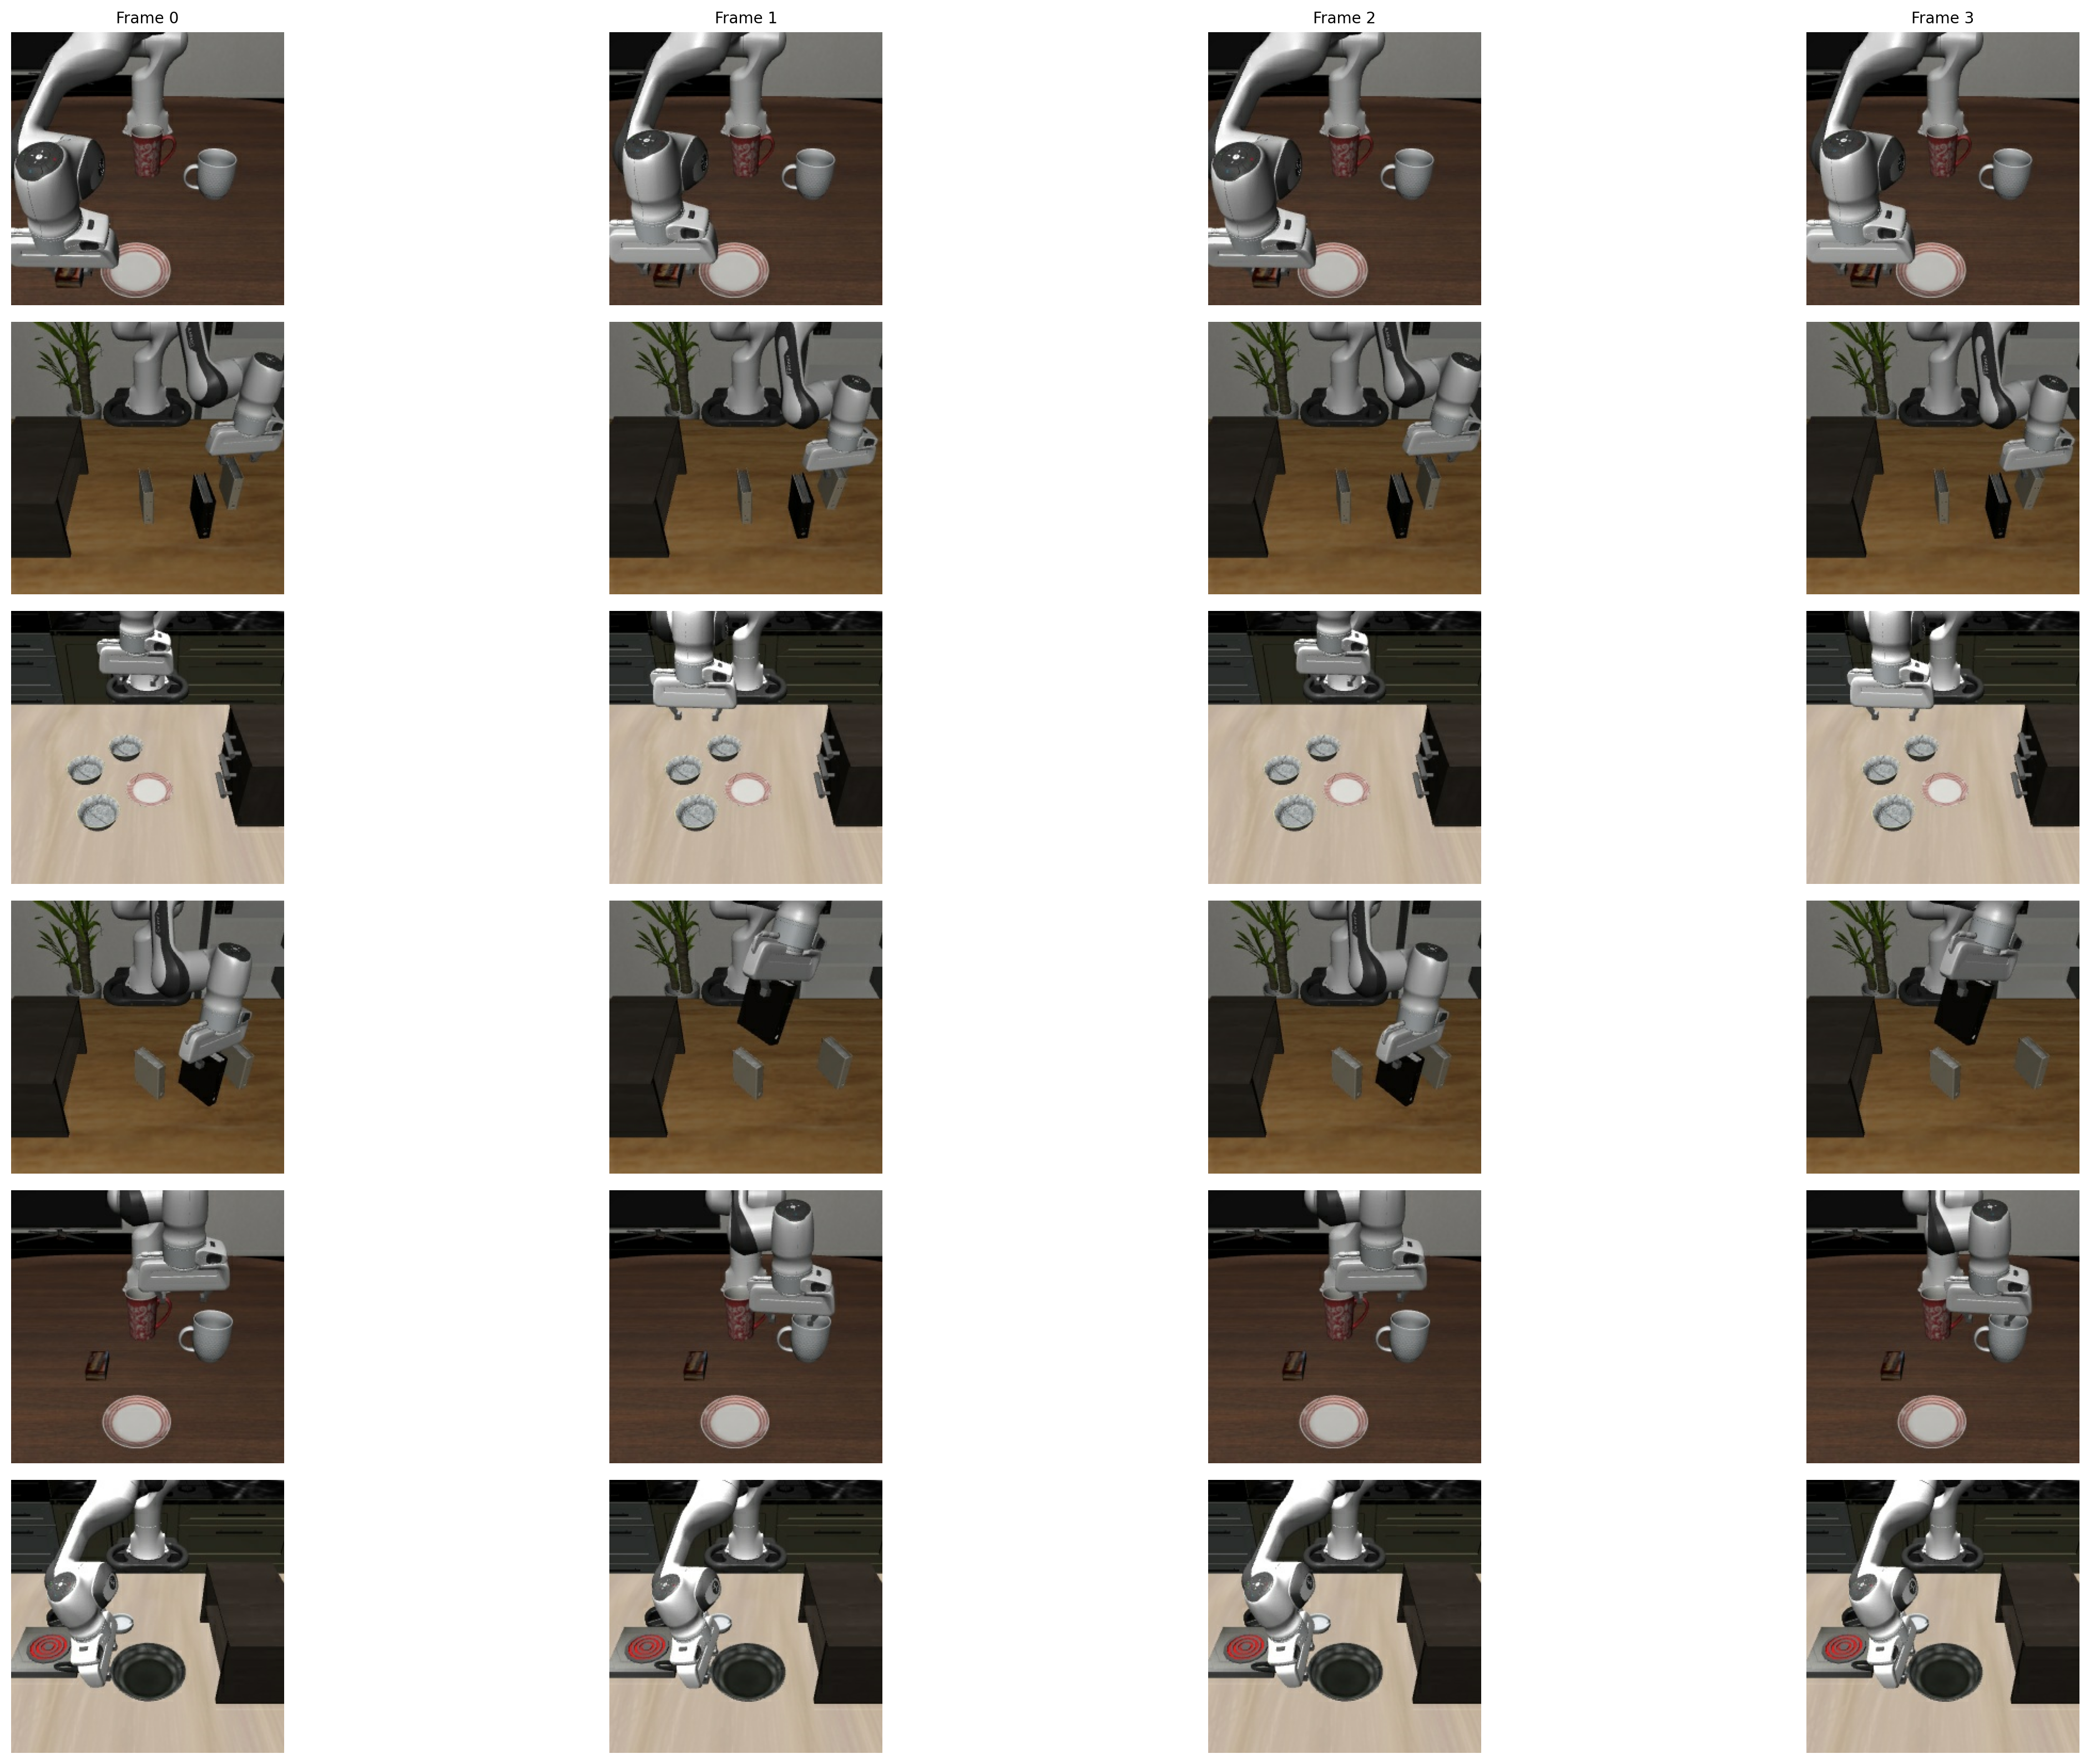

In [8]:

visualize_batch_videos(batch, num_samples=6,denorm=True)

In [9]:
from latent_action_model.core.vjepa_encoder import DINOv3Encoder
from transformers import AutoImageProcessor, AutoModel
import torch.nn.functional as F

path="/mnt/project_rlinf/jlchen/weights/dinov3-vitb16-pretrain-lvd1689m" 
# path="/mnt/project_rlinf/jlchen/weights/dinov3-vitb16-pretrain-lvd1689m" 

# 测试不同的norm方式
videos = batch["videos"].to("cuda")
dec_videos = batch["dec_videos"].to("cuda")

print("=" * 80)
print("测试不同norm方式对DINO特征的影响 - 比较videos[:,0]与videos[:,-1]的差值")
print("=" * 80)

# 1. 无norm
print("\n1. 无norm:")
dino_no_norm = DINOv3Encoder(path, enable_norm=False)
features_no_norm = dino_no_norm.encode(videos, n=-2)
dec_in_no_norm = features_no_norm[:, 0]  # [B, K, D]
tgt_no_norm = features_no_norm[:, -1]    # [B, K, D]
diff_abs_no_norm = (tgt_no_norm - dec_in_no_norm).abs()
diff_mean_no_norm = diff_abs_no_norm.mean()
diff_var_no_norm = diff_abs_no_norm.var()
print(f"  dec_in shape: {dec_in_no_norm.shape}")
print(f"  差值绝对值均值: {diff_mean_no_norm:.6f}")
print(f"  差值绝对值方差: {diff_var_no_norm:.6f}")

# 2. L2 norm
print("\n2. L2 norm:")
dino_l2 = DINOv3Encoder(path, enable_norm=True, norm_layer_type="l2")
features_l2 = dino_l2.encode(videos, n=-2)
dec_in_l2 = features_l2[:, 0]
tgt_l2 = features_l2[:, -1]
diff_abs_l2 = (tgt_l2 - dec_in_l2).abs()
diff_mean_l2 = diff_abs_l2.mean()
diff_var_l2 = diff_abs_l2.var()
print(f"  dec_in shape: {dec_in_l2.shape}")
print(f"  差值绝对值均值: {diff_mean_l2:.6f}")
print(f"  差值绝对值方差: {diff_var_l2:.6f}")

# 3. LayerNorm
print("\n3. LayerNorm:")
dino_ln = DINOv3Encoder(path, enable_norm=True, norm_layer_type="ln")
features_ln = dino_ln.encode(videos, n=-2)
dec_in_ln = features_ln[:, 0]
tgt_ln = features_ln[:, -1]
diff_abs_ln = (tgt_ln - dec_in_ln).abs()
diff_mean_ln = diff_abs_ln.mean()
diff_var_ln = diff_abs_ln.var()
print(f"  dec_in shape: {dec_in_ln.shape}")
print(f"  差值绝对值均值: {diff_mean_ln:.6f}")
print(f"  差值绝对值方差: {diff_var_ln:.6f}")

# 4. BatchNorm
print("\n4. BatchNorm:")
dino_bn = DINOv3Encoder(path, enable_norm=True, norm_layer_type="bn")
features_bn = dino_bn.encode(videos, n=-2)
dec_in_bn = features_bn[:, 0]
tgt_bn = features_bn[:, -1]
diff_abs_bn = (tgt_bn - dec_in_bn).abs()
diff_mean_bn = diff_abs_bn.mean()
diff_var_bn = diff_abs_bn.var()
print(f"  dec_in shape: {dec_in_bn.shape}")
print(f"  差值绝对值均值: {diff_mean_bn:.6f}")
print(f"  差值绝对值方差: {diff_var_bn:.6f}")

# 5. 手动标准化 (mean=0, std=1)
print("\n5. 手动标准化 (mean=0, std=1):")
features_manual = features_no_norm.clone()
features_manual = (features_manual - features_manual.mean(dim=-1, keepdim=True)) / features_manual.std(dim=-1, keepdim=True)
dec_in_manual = features_manual[:, 0]
tgt_manual = features_manual[:, -1]
diff_abs_manual = (tgt_manual - dec_in_manual).abs()
diff_mean_manual = diff_abs_manual.mean()
diff_var_manual = diff_abs_manual.var()
print(f"  dec_in shape: {dec_in_manual.shape}")
print(f"  差值绝对值均值: {diff_mean_manual:.6f}")
print(f"  差值绝对值方差: {diff_var_manual:.6f}")

print("\n" + "=" * 80)
print("总结: 不同norm方式下videos[:,0]与videos[:,-1]的差值统计")
print("=" * 80)
print(f"{'方法':<15} {'绝对值均值':<15} {'绝对值方差':<15}")
print("-" * 80)
print(f"{'无norm':<15} {diff_mean_no_norm:<15.6f} {diff_var_no_norm:<15.6f}")
print(f"{'L2 norm':<15} {diff_mean_l2:<15.6f} {diff_var_l2:<15.6f}")
print(f"{'LayerNorm':<15} {diff_mean_ln:<15.6f} {diff_var_ln:<15.6f}")
print(f"{'BatchNorm':<15} {diff_mean_bn:<15.6f} {diff_var_bn:<15.6f}")
print(f"{'手动标准化':<15} {diff_mean_manual:<15.6f} {diff_var_manual:<15.6f}")

# 使用L2 norm作为默认方式
dino = dino_l2
dec_in_video = features_l2
dec_in_dino = dec_in_video[:,0].float() 
tgt_dino = dec_in_video[:,-1].float()
print(f"\n最终使用特征shape: {dec_in_video.shape}")

测试不同norm方式对DINO特征的影响 - 比较videos[:,0]与videos[:,-1]的差值

1. 无norm:


  dec_in shape: torch.Size([128, 256, 768])
  差值绝对值均值: 4.143468
  差值绝对值方差: 35.593662

2. L2 norm:
  dec_in shape: torch.Size([128, 256, 768])
  差值绝对值均值: 0.010717
  差值绝对值方差: 0.000239

3. LayerNorm:
  dec_in shape: torch.Size([128, 256, 768])
  差值绝对值均值: 0.296966
  差值绝对值方差: 0.183717

4. BatchNorm:
  dec_in shape: torch.Size([128, 256, 768])
  差值绝对值均值: 0.409911
  差值绝对值方差: 0.236985

5. 手动标准化 (mean=0, std=1):
  dec_in shape: torch.Size([128, 256, 768])
  差值绝对值均值: 0.296773
  差值绝对值方差: 0.183478

总结: 不同norm方式下videos[:,0]与videos[:,-1]的差值统计
方法              绝对值均值           绝对值方差          
--------------------------------------------------------------------------------
无norm           4.143468        35.593662      
L2 norm         0.010717        0.000239       
LayerNorm       0.296966        0.183717       
BatchNorm       0.409911        0.236985       
手动标准化           0.296773        0.183478       

最终使用特征shape: torch.Size([128, 2, 256, 768])


In [20]:
dec_in = videos[:,0]
tgt = videos[:,-1]

index=5

In [ ]:
dec_in_dino = dino.encode(videos,n=11)[-1]
# tgt_dino = dino.encode(tgt,n=24)[-1].reshape(6,-1,1024)
print(dec_in_dino.std())
print(dec_in_dino.mean())
print(dec_in_dino.abs().mean())

tensor(1.7386, device='cuda:0')
tensor(-0.1782, device='cuda:0')
tensor(0.7753, device='cuda:0')


In [9]:
from latent_action_model.core.lam_model import load_latent_action_model

print(batch["videos"].shape)
videos = batch["videos"].to("cuda")
states = batch["proprio"].to("cuda")
dec_videos = batch["dec_videos"].to("cuda")
dec_in = dec_videos[:,0]
tgt = dec_videos[:,-1]
lam_ckpt_path= "/mnt/project_rlinf/jlchen/code/UniVLA/latent_action_model/logs/dino_base_2q_16_bigwin/version_1/checkpoints/epoch=4.ckpt"
lam_yaml_path= "/mnt/project_rlinf/jlchen/code/UniVLA/latent_action_model/logs/dino_base_2q_16_bigwin/version_1/dino_base.yaml"
# lam_ckpt_path= "/mnt/project_rlinf/jlchen/code/UniVLA/latent_action_model/logs/dino_base_4q_32_bigwin/version_3/checkpoints/epoch=14.ckpt"
# lam_yaml_path= "/mnt/project_rlinf/jlchen/code/UniVLA/latent_action_model/logs/dino_base_4q_32_bigwin/version_3/dino_base.yaml"
# lam_ckpt_path= "/mnt/project_rlinf/jlchen/code/UniVLA/latent_action_model/logs/dino_base_ae_bigwin/version_0/checkpoints/epoch=21.ckpt"
# lam_yaml_path= "/mnt/project_rlinf/jlchen/code/UniVLA/latent_action_model/logs/dino_base_ae_bigwin/version_0/dino_base_ae.yaml"
lam = load_latent_action_model(lam_ckpt_path, lam_yaml_path)
# path_lam= "/mnt/project_rlinf/jlchen/code/UniVLA/latent_action_model/logs/dino_bridge_bi/version_2/checkpoints/epoch=9.ckpt"
# lam = load_latent_action_model(path_lam,"dino",encoder=LAMEncoder)
lam = lam.to("cuda").eval()
lam_feature = lam.vq_encode(videos,states,dec_videos=dec_videos,predict_future_frame=True)
tgt_dino = lam_feature["tgt"]
recon_dino = lam_feature["recon"]
dec_in_dino = lam_feature["dec_in"]
# print(lam_feature["indices"][:6])


torch.Size([128, 2, 3, 256, 256])


In [ ]:
print(lam_feature["quantized"].mean())
print(lam_feature["quantized"].std())

tensor(0.0090, device='cuda:0')
tensor(0.5212, device='cuda:0')


In [10]:
# 反复迭代此batch的数据，检查得到的索引是否和初始batch的索引一致
initial_indices = lam_feature["indices"].clone()
num_iterations = 10

for i in range(num_iterations):
    lam_feature_iter = lam.vq_encode(videos, states, dec_videos=dec_videos, predict_future_frame=True)
    current_indices = lam_feature_iter["indices"]
    
    # 检查是否一致
    if not torch.equal(initial_indices, current_indices):
        print(f"迭代 {i+1}: 索引不一致!")
        print(f"初始索引[:6]:\n{initial_indices[:6]}")
        print(f"当前索引[:6]:\n{current_indices[:6]}")
        print(f"差异位置数量: {(initial_indices != current_indices).sum().item()}")
        break
else:
    print(f"完成 {num_iterations} 次迭代，所有索引均保持一致")
    print(f"索引[:6]:\n{initial_indices[:6]}")

完成 10 次迭代，所有索引均保持一致
索引[:6]:
tensor([[ 6, 31,  7, 17],
        [15, 19, 21, 12],
        [23, 22, 20,  3],
        [ 0, 25,  9,  3],
        [ 0, 19,  7, 30],
        [23, 22,  9, 30]], device='cuda:0')


In [11]:
print(dec_in_dino.mean())
print(dec_in_dino.std())

tensor(5.7238e-10, device='cuda:0')
tensor(1.0000, device='cuda:0')


In [59]:
import torch

# 计算 codebook 中指定索引的 embedding 差值（支持批量索引）
with torch.inference_mode():
    codebook = lam.vq.get_codebooks()  # [K, D]
    selected_indices = torch.tensor([3, 11], device=codebook.device, dtype=torch.long)
    selected_embeddings = codebook[selected_indices]  # [N, D]

    # 两两差值: diff[i, j] = emb[i] - emb[j]
    pairwise_diff = selected_embeddings.unsqueeze(1) - selected_embeddings.unsqueeze(0)
    pairwise_l2 = pairwise_diff.norm(dim=-1)
    pairwise_abs_mean = pairwise_diff.abs().mean()

    print("codebook indices:", selected_indices.tolist())
    print("pairwise embedding diff shape:", pairwise_diff.shape)
    print("mean |diff|:", float(pairwise_abs_mean))
    # print("pairwise diff:\n", pairwise_diff.cpu())
    # print("pairwise L2 norm:\n", pairwise_l2.cpu())



codebook indices: [3, 11]
pairwise embedding diff shape: torch.Size([2, 2, 64])
mean |diff|: 0.15996390581130981


In [11]:
indices = lam_feature["indices"]
print("Original indices shape:", indices.shape)
print("Original indices:\n", indices[:6])

# 将每一列转化为 one-hot 计数
# indices shape: [B, num_queries]
B, num_queries = indices.shape
codebook_size = lam.codebook_size

# 对每一列进行 one-hot 计数
onehot_counts = []
for col_idx in range(num_queries):
    col = indices[:, col_idx]  # [B]
    # 统计该列中每个 code 出现的次数
    counts = torch.bincount(col, minlength=codebook_size)
    onehot_counts.append(counts)

onehot_counts = torch.stack(onehot_counts, dim=0)  # [num_queries, codebook_size]
print("\nOne-hot counts shape:", onehot_counts.shape)
print("One-hot counts (each row is a column from indices):\n", onehot_counts.cpu().numpy())

Original indices shape: torch.Size([128, 2])
Original indices:
 tensor([[ 0,  6],
        [ 9, 14],
        [ 1,  3],
        [ 2,  3],
        [ 0,  3],
        [ 2,  6]], device='cuda:0')

One-hot counts shape: torch.Size([2, 16])
One-hot counts (each row is a column from indices):
 [[19 10 18  1  0  0  0  0 18 22 25  0  6  0  0  9]
 [ 0  0  0 26 22  1 44  0  0  0  0  2  0 16 17  0]]


In [26]:
lam_feature = lam.vq_encode(videos,states,dec_videos=dec_videos,predict_future_frame=True,user_specific=[10,  11, 16, 14])
tgt_dino = lam_feature["tgt"]                                                                       
recon_dino = lam_feature["recon"]
dec_in_dino = lam_feature["dec_in"]

In [ ]:
print(tgt_dino.norm(dim=-1).mean())
print(F.cosine_similarity(tgt_dino,recon_dino,dim=-1).mean())
print(F.cosine_similarity(dec_in_dino,recon_dino,dim=-1).mean())
print(F.cosine_similarity(dec_in_dino,tgt_dino,dim=-1).mean())

tensor(27.7128, device='cuda:0')
tensor(0.9262, device='cuda:0')
tensor(0.8990, device='cuda:0')
tensor(0.8445, device='cuda:0')


In [12]:
print(abs(tgt_dino).mean())
print(abs(dec_in_dino).mean())
print(abs(dec_in_dino-tgt_dino).mean())

tensor(0.6578, device='cuda:0')
tensor(0.6575, device='cuda:0')
tensor(0.3196, device='cuda:0')


In [17]:
corr_0 = torch.corrcoef(torch.stack([dec_in_dino.flatten(), tgt_dino.flatten()]))[0,1]
print(f"corr(dec_in_dino, tgt_dino): {corr_0.item():.6f}")

# 检查输入输出的相关性
x = dec_in_dino.flatten()
y = recon_dino.flatten()

corr_1 = torch.corrcoef(torch.stack([x, y]))[0, 1].item()

x2 = tgt_dino.flatten()
y2 = recon_dino.flatten()

corr_2 = torch.corrcoef(torch.stack([x2, y2]))[0, 1].item()

print(f"corr(dec_in_dino, recon_dino): {corr_1:.6f}")
print(f"corr(tgt_dino, recon_dino): {corr_2:.6f}")


corr(dec_in_dino, tgt_dino): 0.887187
corr(dec_in_dino, recon_dino): 0.930659
corr(tgt_dino, recon_dino): 0.948758


In [ ]:
print(recon_dino.shape)

# tgt_dino = tgt_dino[:,0].float()
tgt_dino = recon_dino[:,0].float()
# recon_dino = recon_dino[:,5:]
dec_in_dino = dec_in_dino[:,0].float()
print(tgt_dino.abs().mean())
# dec_in_dino = recon_dino[:,0].float()

torch.Size([128, 1, 256, 768])
tensor(0.5927, device='cuda:0')


In [ ]:
index=5

In [ ]:
import torch.nn.functional as F
import numpy as np
from sklearn.decomposition import PCA

# 检查特征形状
print(f"dec_in_dino shape: {dec_in_dino.shape}")
print(f"tgt_dino shape: {tgt_dino.shape}")

# DINO 输出格式：[B, num_tokens, dim]
# 其中 num_tokens = 1 (CLS) + 4 (register) + 196 (patch) = 201
# 我们需要排除前 5 个 tokens（CLS + register），只使用 patch tokens
B, num_tokens, dim = dec_in_dino.shape

# # 提取 patch tokens（跳过前 5 个：CLS token + 4 个 register tokens）
# # 索引 0: CLS token
# # 索引 1-4: 4 个 register tokens
# # 索引 5-200: 196 个 patch tokens
dec_in_patches = dec_in_dino  # [B, 196, dim]
tgt_patches = tgt_dino  # [B, 196, dim]
assert dec_in_patches.shape[1]==256
assert tgt_patches.shape[1]==256
# 假设是 224x224 图像，patch_size=16，则 H*W = 14*14 = 196
patch_size = 16
image_size = 256
h_patches = image_size // patch_size  # 14
w_patches = image_size // patch_size  # 14

# 对齐 dense_sparse_matching.ipynb 的格式：[dim, H, W]
# 取第一个样本，然后 reshape 和 permute
dec_in_feats = dec_in_patches[index].permute(1, 0).view(dim, h_patches, w_patches)  # [dim, H, W]
tgt_feats = tgt_patches[index].permute(1, 0).view(dim, h_patches, w_patches)  # [dim, H, W]

print(f"dec_in_feats shape (aligned with dense_sparse_matching format): {dec_in_feats.shape}")
print(f"tgt_feats shape (aligned with dense_sparse_matching format): {tgt_feats.shape}")

# 归一化：对齐 dense_sparse_matching.ipynb 的方式
# 在 [dim, H, W] 格式上沿着 dim=0（特征维度）归一化
dec_in_feats = F.normalize(dec_in_feats, p=2, dim=0)
tgt_feats = F.normalize(tgt_feats, p=2, dim=0)

# 计算相似度矩阵：对齐 dense_sparse_matching.ipynb 的方式
# 使用 einsum，左侧转换为 [H*W, dim]，右侧保持 [dim, H, W]
heatmaps = torch.einsum(
    "k f, f h w -> k h w",
    dec_in_feats.view(dim, -1).permute(1, 0),  # [H*W, dim]
    tgt_feats,  # [dim, H, W]
)

print(f"Heatmaps shape: {heatmaps.shape}")  # [H*W, H, W] = [196, 14, 14]

# 为了后续可视化，也计算完整的相似度矩阵 [H*W, H*W]
dec_in_flat = dec_in_feats.view(dim, -1).permute(1, 0)  # [H*W, dim] = [196, dim]
tgt_flat = tgt_feats.view(dim, -1).permute(1, 0)  # [H*W, dim] = [196, dim]

# 相似度矩阵: [H*W, H*W] = [196, 196]
similarity_matrix = torch.matmul(dec_in_flat, tgt_flat.t())  # [196, 196]

print(f"Similarity matrix shape: {similarity_matrix.shape}")
print(f"Similarity range: [{similarity_matrix.min():.3f}, {similarity_matrix.max():.3f}]")
print(f"✅ 格式已对齐 dense_sparse_matching.ipynb：特征格式 [dim, H, W]，归一化沿着 dim=0")


dec_in_dino shape: torch.Size([128, 256, 768])
tgt_dino shape: torch.Size([128, 256, 768])
dec_in_feats shape (aligned with dense_sparse_matching format): torch.Size([768, 16, 16])
tgt_feats shape (aligned with dense_sparse_matching format): torch.Size([768, 16, 16])
Heatmaps shape: torch.Size([256, 16, 16])
Similarity matrix shape: torch.Size([256, 256])
Similarity range: [-0.014, 0.997]
✅ 格式已对齐 dense_sparse_matching.ipynb：特征格式 [dim, H, W]，归一化沿着 dim=0


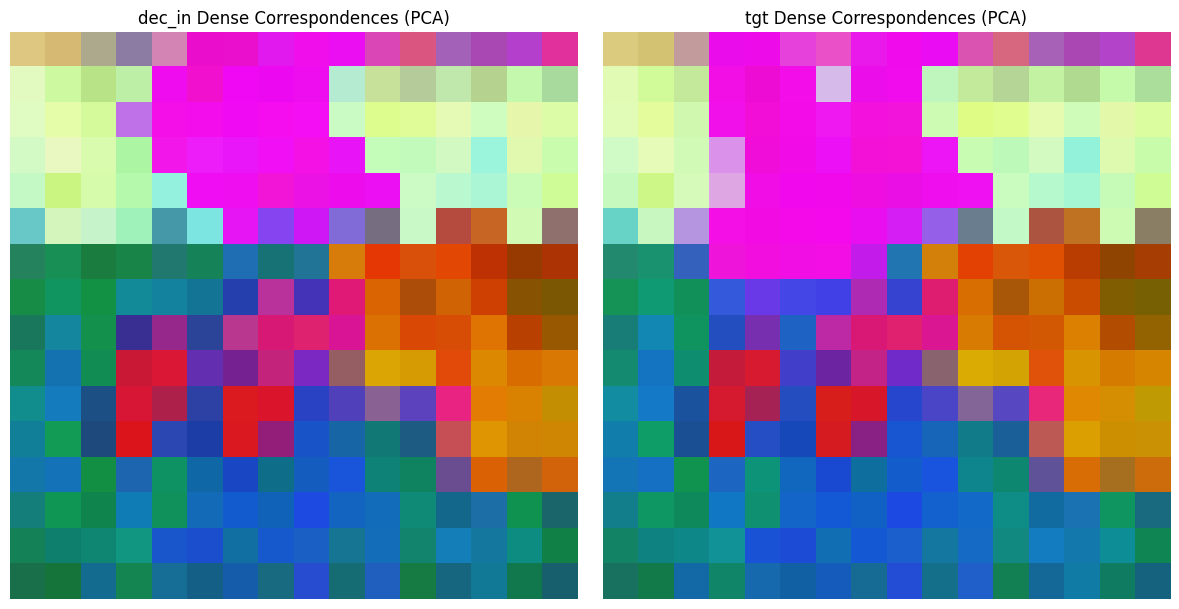

In [ ]:
# 使用 PCA 将特征投影到颜色空间进行可视化（对齐 dense_sparse_matching.ipynb）

# 对齐 dense_sparse_matching.ipynb：使用所有 patch 进行 PCA 拟合
pca = PCA(n_components=3, whiten=True)
# 将特征从 [dim, H, W] 转换为 [H*W, dim] 用于 PCA
x_dec_in = dec_in_feats.view(dim, -1).permute(1, 0)  # [H*W, dim]
pca.fit(x_dec_in.detach().cpu().numpy())
# 为 dec_in 生成颜色（对齐 dense_sparse_matching.ipynb）
h_patches_dec_in = dec_in_feats.shape[1]
w_patches_dec_in = dec_in_feats.shape[2]
projected_dec_in = torch.from_numpy(
    pca.transform(x_dec_in.detach().cpu().numpy())
).view(h_patches_dec_in, w_patches_dec_in, 3)
# 使用 sigmoid 增强颜色对比度（对齐 dense_sparse_matching.ipynb）
projected_dec_in = F.sigmoid(projected_dec_in.mul(2.0)).permute(2, 0, 1)  # [3, H, W]


# 为 tgt 生成颜色（对齐 dense_sparse_matching.ipynb）
h_patches_tgt = tgt_feats.shape[1]
w_patches_tgt = tgt_feats.shape[2]
x_tgt = tgt_feats.view(dim, -1).permute(1, 0)  # [H*W, dim]
projected_tgt = torch.from_numpy(
    pca.transform(x_tgt.detach().cpu().numpy())
).view(h_patches_tgt, w_patches_tgt, 3)
projected_tgt = F.sigmoid(projected_tgt.mul(2.0)).permute(2, 0, 1)  # [3, H, W]

# 可视化 PCA 投影结果（对齐 dense_sparse_matching.ipynb）
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(projected_dec_in.permute(1, 2, 0).cpu().numpy())
axes[0].set_title("dec_in Dense Correspondences (PCA)", fontsize=12)
axes[0].axis('off')

axes[1].imshow(projected_tgt.permute(1, 2, 0).cpu().numpy())
axes[1].set_title("tgt Dense Correspondences (PCA)", fontsize=12)
axes[1].axis('off')
plt.tight_layout()
plt.show()
plt.close()


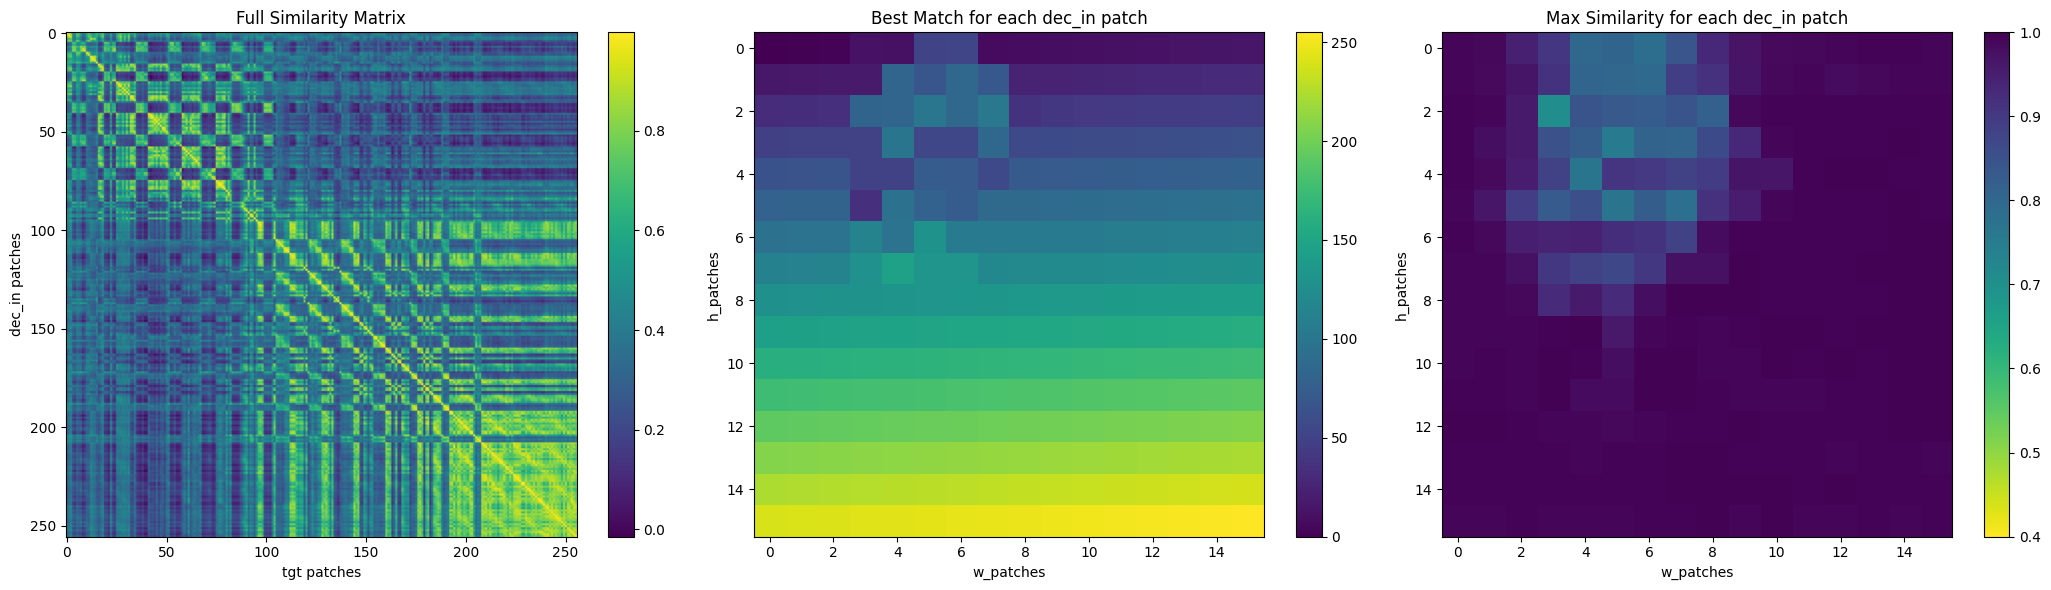

In [ ]:
# 可视化相似度矩阵热图

# 将相似度矩阵 reshape 为 [H1*W1, H2*W2]，然后显示
similarity_np = similarity_matrix.detach().cpu().numpy()

# 创建热图
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# 1. 显示完整的相似度矩阵
im1 = axes[0].imshow(similarity_np, cmap='viridis', aspect='auto')
axes[0].set_title("Full Similarity Matrix", fontsize=12)
axes[0].set_xlabel("tgt patches")
axes[0].set_ylabel("dec_in patches")
plt.colorbar(im1, ax=axes[0])

# 2. 显示每个 dec_in patch 对应的最佳匹配（argmax）
best_matches = similarity_matrix.argmax(dim=1).cpu().numpy()  # [H1*W1]
best_matches_2d = best_matches.reshape(h_patches, w_patches)
# best_h = (best_matches // 14).reshape(h_patches, w_patches)   # 目标行坐标
# best_w = (best_matches %  14).reshape(h_patches, w_patches)   # 目标列坐标
# axes[3].imshow(best_h), axes[4].imshow(best_w)
im2 = axes[1].imshow(best_matches_2d, cmap='viridis', aspect='auto')
axes[1].set_title("Best Match for each dec_in patch", fontsize=12)
axes[1].set_xlabel("w_patches")
axes[1].set_ylabel("h_patches")
plt.colorbar(im2, ax=axes[1])

# 3. 显示每个 dec_in patch 的最大相似度值
max_similarities = similarity_matrix.max(dim=1).values.detach().cpu().numpy()  # [H1*W1]
max_sim_2d = max_similarities.reshape(h_patches, w_patches)
im3 = axes[2].imshow(max_sim_2d, cmap='viridis_r', aspect='auto',vmin=0.4,vmax=1)
axes[2].set_title("Max Similarity for each dec_in patch", fontsize=12)
axes[2].set_xlabel("w_patches")
axes[2].set_ylabel("h_patches")
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()
plt.close()


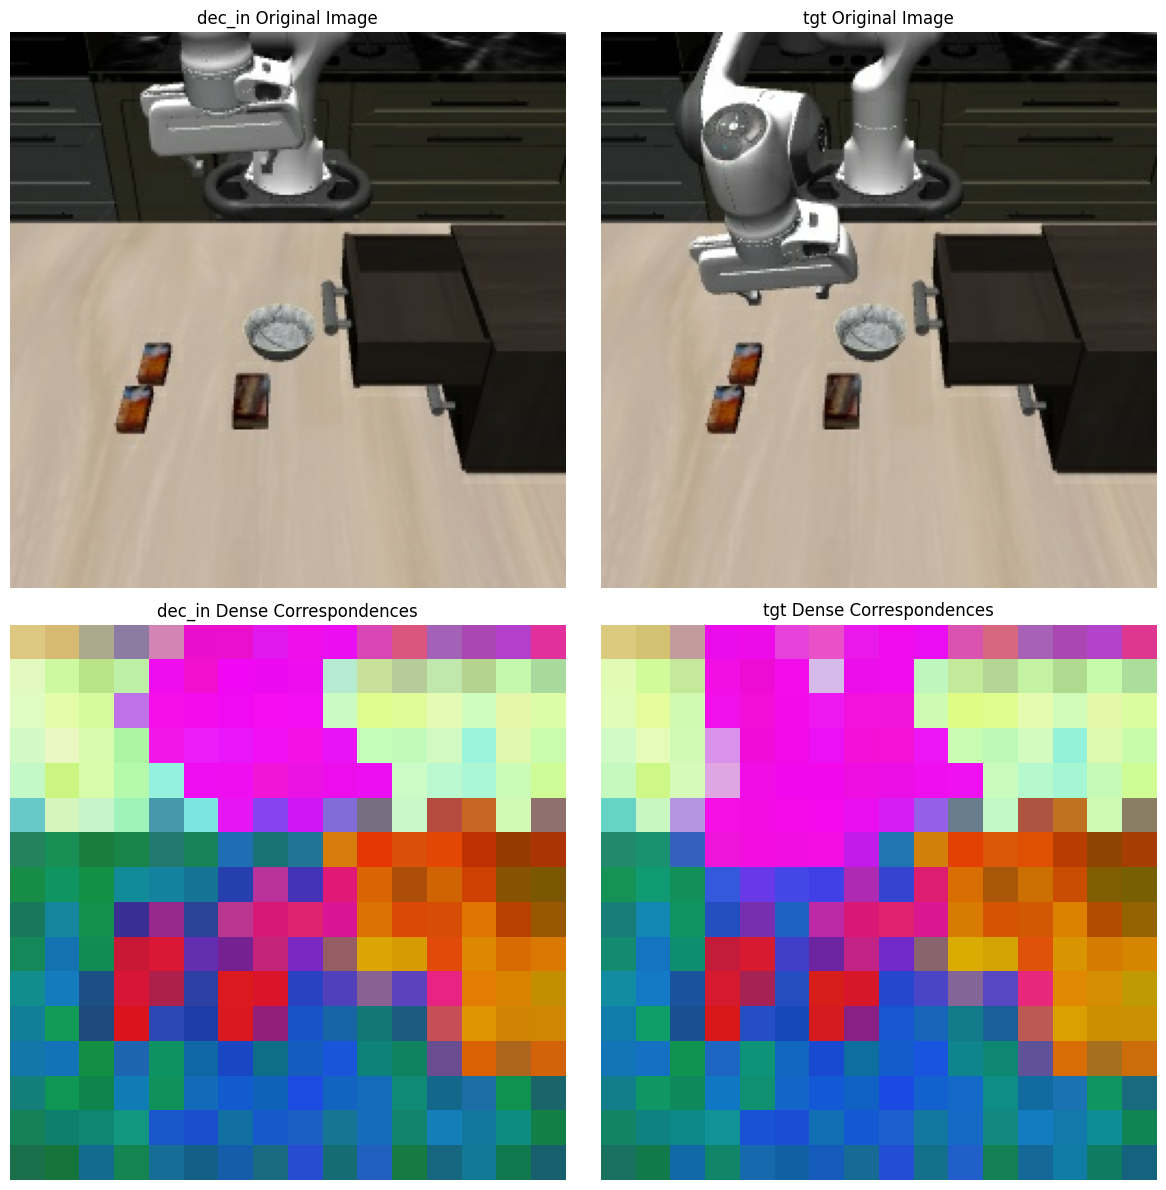

In [ ]:
# 可视化原始图像和稠密相关性对比

# 获取原始图像（反归一化）
dec_in_img = denorm_for_vis(dec_in[index]).permute(1, 2, 0).cpu().numpy()
tgt_img = denorm_for_vis(tgt[index]).permute(1, 2, 0).cpu().numpy()
# 创建对比图
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# 第一行：原始图像
axes[0, 0].imshow(dec_in_img)
axes[0, 0].set_title("dec_in Original Image", fontsize=12)
axes[0, 0].axis('off')

# axes[0, 1].imshow(dec_in_img_1)
axes[0, 1].imshow(tgt_img)
axes[0, 1].set_title("tgt Original Image", fontsize=12)
axes[0, 1].axis('off')

# 第二行：PCA 投影的稠密相关性
axes[1, 0].imshow(projected_dec_in.permute(1, 2, 0).cpu().numpy())
axes[1, 0].set_title("dec_in Dense Correspondences", fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(projected_tgt.permute(1, 2, 0).cpu().numpy())
# axes[1, 1].imshow(projected_dec_in_1.permute(1, 2, 0).cpu().numpy())
axes[1, 1].set_title("tgt Dense Correspondences", fontsize=12)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()
plt.close()


torch.Size([768, 16, 16])


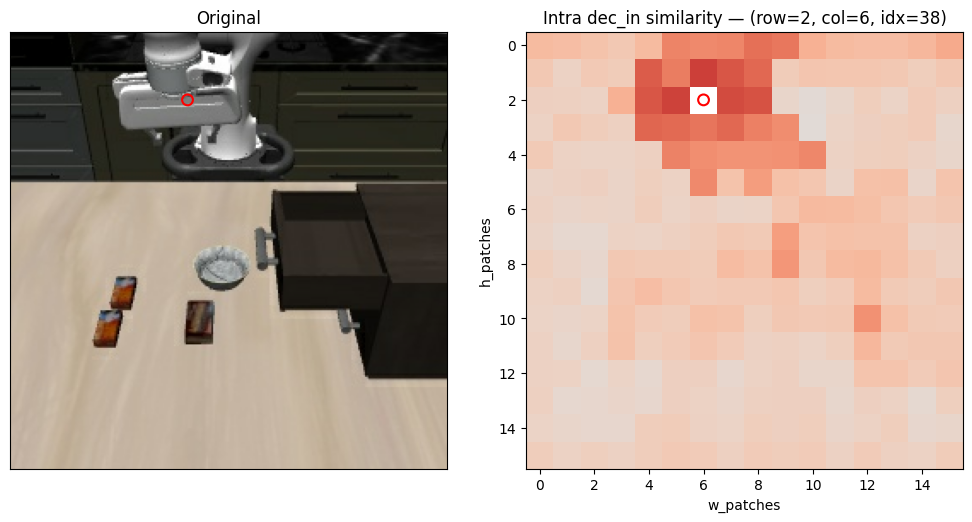

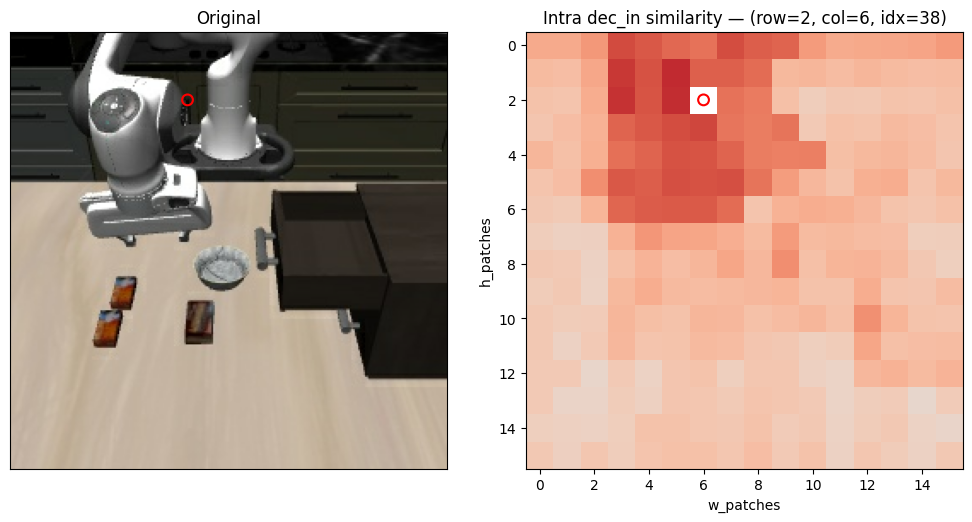

In [ ]:
print(dec_in_feats.shape)
row=2
col=6
# sim = visualize_self_similarity(dec_in_feats, row=row, col=col, orig_image=tgt_img, mask_self=True, show_colorbar=True)
sim = visualize_self_similarity(dec_in_feats, row=row, col=col, orig_image=dec_in_img, mask_self=True, show_colorbar=False)
sim = visualize_self_similarity(tgt_feats, row=row, col=col, orig_image=tgt_img, mask_self=True, show_colorbar=False)

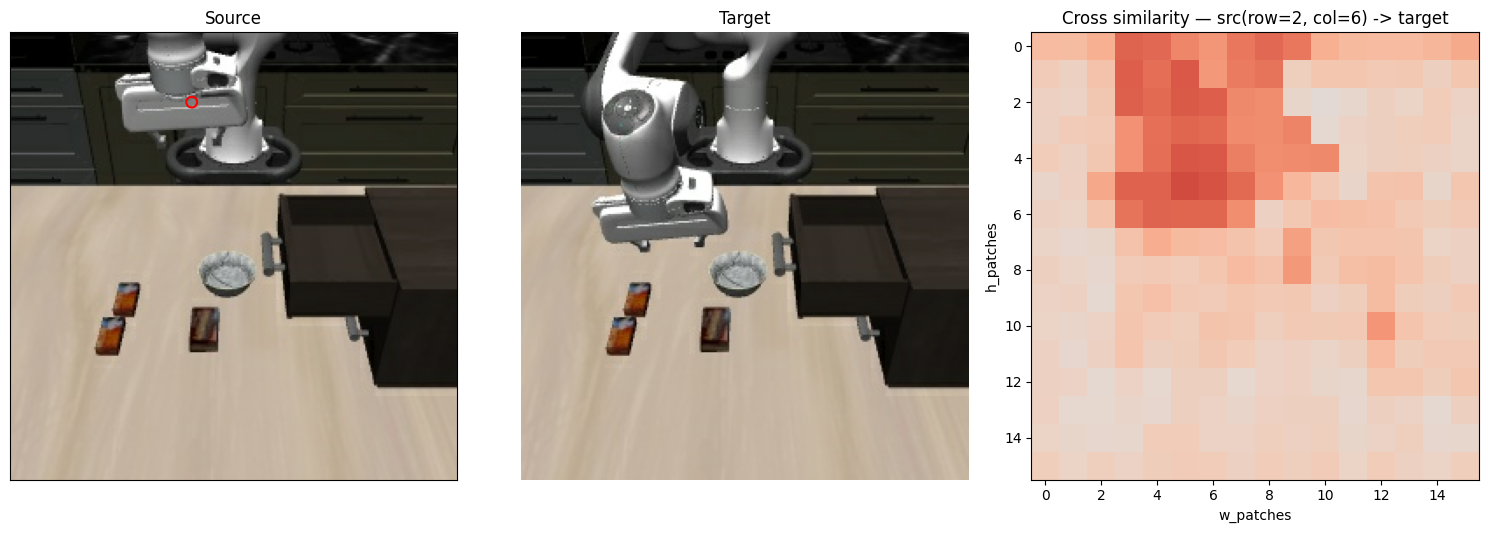

In [ ]:
sim_cross = visualize_cross_image_similarity(
    src_feats=dec_in_feats,
    dst_feats=tgt_feats,
    src_row=row, src_col=col,
    src_image=dec_in_img,      # 可选
    dst_image=tgt_img,         # 可选
    overlay_on_dst=False,      # 若 True 则把热图叠加到目标原图上
    show_colorbar=False        # 默认 False
)


In [27]:
print(F.cosine_similarity(dec_in_feats,tgt_feats, dim=0).mean())
print(F.cosine_similarity(dec_in_dino[index],tgt_dino[index], dim=-1).mean())
print((dec_in_dino[index]-tgt_dino[index]).abs().mean())


tensor(0.9197, device='cuda:0')
tensor(0.9197, device='cuda:0')
tensor(0.1772, device='cuda:0')


In [42]:

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 可视化 CLS token 与图像 patch 特征的相似度（同一图像）
# 需要 DINOv3Encoder.encode 支持 remove_cls=False
with torch.inference_mode():
    # 获取包含 CLS+register+patch 的完整 token 特征
    dec_all_tokens = lam.vision_encoder.encode(dec_in, remove_cls=False).squeeze(1)  # [B, 1+4+196, D]
    tgt_all_tokens = lam.vision_encoder.encode(tgt, remove_cls=False).squeeze(1)    # [B, 1+4+196, D]

# 选择一个样本索引
b = int(index)
# b=0
# 取出 CLS 与 patch tokens（DINO: 0 为 CLS，1-4 为 register，5: 开始为 patch）
dec_tokens_b = dec_all_tokens[b]  # [Tkn, D]
tgt_tokens_b = tgt_all_tokens[b]
cls_dec = F.normalize(dec_tokens_b[0], dim=-1)
cls_tgt = F.normalize(tgt_tokens_b[0], dim=-1)
patch_dec = F.normalize(dec_tokens_b[5:], dim=-1)  # [196, D]
patch_tgt = F.normalize(tgt_tokens_b[5:], dim=-1)  # [196, D]

# 计算 CLS 与 patch 的余弦相似度
sim_dec = F.cosine_similarity(cls_dec.unsqueeze(0), patch_dec, dim=-1)  # [196]
sim_tgt = F.cosine_similarity(cls_tgt.unsqueeze(0), patch_tgt, dim=-1)  # [196]

# 重塑为 14x14 热图（适配 224x224 / 16x16 patch）
h = w = int(patch_dec.shape[0] ** 0.5)
sim_dec_map = sim_dec.view(h, w).detach().cpu()
sim_tgt_map = sim_tgt.view(h, w).detach().cpu()

# 原图（反标准化到 [0,1]）
dec_img_np = denorm_for_vis(dec_in[b]).permute(1, 2, 0).cpu().numpy()
tgt_img_np = denorm_for_vis(tgt[b]).permute(1, 2, 0).cpu().numpy()

# 展示：原图 + 热力图（叠加）
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(dec_img_np)
axes[0, 0].set_title("dec_in 原图")
axes[0, 0].axis('off')
axes[0, 1].imshow(dec_img_np)
im0 = axes[0, 1].imshow(sim_dec_map.numpy(), cmap='viridis',  alpha=0.55)
axes[0, 1].set_title("CLS 与 dec_in patches 相似度")
axes[0, 1].axis('off')

axes[1, 0].imshow(tgt_img_np)
axes[1, 0].set_title("tgt 原图")
axes[1, 0].axis('off')
axes[1, 1].imshow(tgt_img_np)
im1 = axes[1, 1].imshow(sim_tgt_map.numpy(), cmap='viridis',  alpha=0.55)
axes[1, 1].set_title("CLS 与 tgt patches 相似度")
axes[1, 1].axis('off')

cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
fig.colorbar(im1, cax=cbar_ax, label='cosine similarity')
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()
plt.close()

print({
    'dec_in_cls_mean_sim': float(sim_dec.mean().cpu()),
    'dec_in_cls_min_sim': float(sim_dec.min().cpu()),
    'dec_in_cls_max_sim': float(sim_dec.max().cpu()),
    'tgt_cls_mean_sim': float(sim_tgt.mean().cpu()),
    'tgt_cls_min_sim': float(sim_tgt.min().cpu()),
    'tgt_cls_max_sim': float(sim_tgt.max().cpu()),
})

AssertionError: DINOv3Encoder 期望的 BN 层数为 1，但传入的特征层数为 4；请保证两者一致（通常为 len(latent_layer_to_use)）。

2026-01-05 10:36:51.639590: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:284: Filling up shuffle buffer (this may take a while): 988 of 2048
2026-01-05 10:37:01.665296: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:284: Filling up shuffle buffer (this may take a while): 2008 of 2048
2026-01-05 10:37:02.045372: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.
2026-01-05 10:37:07.896498: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.


[1, 5, 0, 5, 12, 13, 10, 3, 8, 13, 2, 5, 1, 13, 12, 13, 9, 6, 9, 3, 8, 6, 0, 11, 7, 13, 10, 4, 12, 14, 1, 5, 2, 3, 7, 5, 9, 5, 8, 5, 2, 5, 12, 14, 2, 11, 10, 4, 2, 14, 7, 3, 12, 11, 8, 14, 2, 5, 9, 6, 12, 13, 8, 3, 2, 4, 8, 4, 0, 11, 7, 11, 2, 3, 2, 3, 8, 5, 10, 4, 2, 6, 9, 3, 12, 14, 7, 6, 2, 5, 2, 13, 8, 14, 1, 14, 7, 5, 9, 13, 9, 3, 8, 5, 1, 13, 2, 11, 7, 3, 15, 6, 9, 14, 8, 14, 1, 5, 12, 14, 9, 3, 1, 11, 9, 3, 8, 6, 9, 13, 2, 11, 1, 6, 12, 5, 8, 5, 2, 3, 1, 5, 10, 5, 1, 14, 10, 3, 2, 13, 2, 11, 0, 11, 9, 4, 0, 11, 12, 3, 12, 5, 9, 6, 8, 14, 1, 3, 8, 14, 9, 14, 2, 6, 9, 13, 2, 5, 9, 13, 9, 14, 1, 14, 15, 13, 8, 11, 7, 14, 9, 6, 0, 6, 0, 5, 12, 3, 2, 6, 8, 6, 2, 11, 15, 6, 2, 5, 15, 4, 9, 5, 8, 11, 9, 14, 2, 6, 9, 14, 15, 5, 2, 4, 2, 14, 0, 11, 7, 6, 0, 5, 8, 11, 9, 13, 9, 14, 2, 11, 12, 3, 12, 14, 0, 14, 9, 5, 10, 13, 0, 3, 7, 6, 12, 14, 12, 14, 10, 13, 15, 4, 2, 5, 10, 13, 10, 13, 7, 6, 0, 11, 8, 13, 12, 5, 15, 14, 12, 11, 2, 14, 7, 5, 8, 14, 15, 6, 8, 6, 9, 4, 8, 3, 1, 5, 2, 3, 12

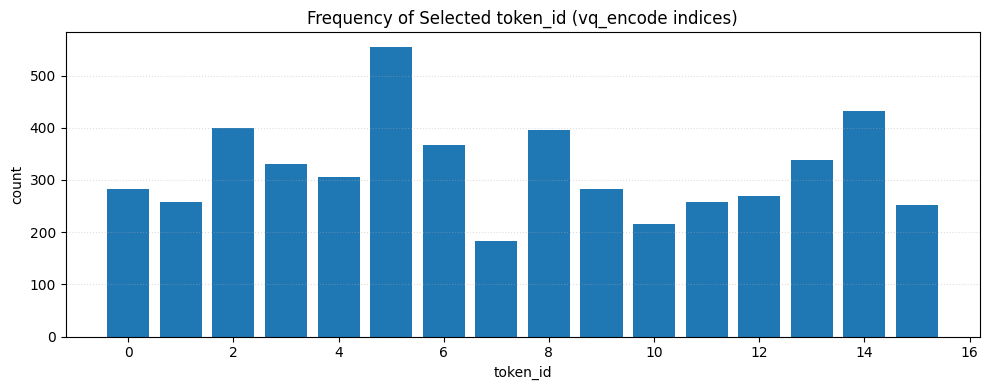

[0. 1.]


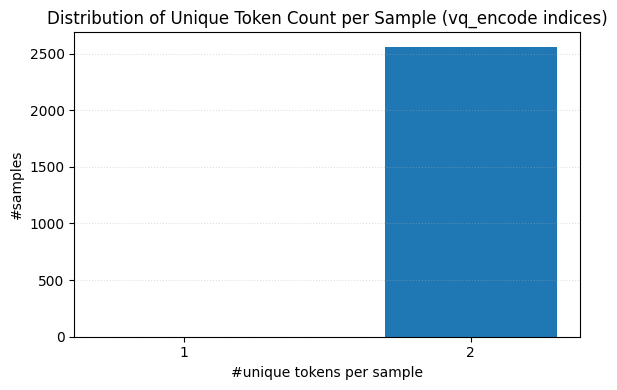

In-memory variables: all_selected_token_ids, per_sample_unique_counts


In [24]:
import torch
import numpy as np
import matplotlib.pyplot as plt

all_selected_token_ids = []
per_sample_unique_counts = []

# 遍历数据加载器，使用 lam.vq_encode 获取索引
num_iters = 20
iterator = iter(train_loader)

device = next(lam.parameters()).device

with torch.inference_mode():
    for i in range(num_iters):
        try:
            batch = next(iterator)
        except StopIteration:
            iterator = iter(train_loader)
            batch = next(iterator)

        videos = batch["videos"].to(device)
        states = (batch["states"] if "states" in batch else batch["proprio"]).to(device)
        # 与训练时保持一致，使用 dec_videos 作为解码输入
        dec_videos = batch["dec_videos"].to(device)

        # 正确调用 vq_encode：只传入 videos / states / dec_videos
        out = lam.vq_encode(videos, states, dec_videos=dec_videos, predict_future_frame=False)
        idx = out["indices"].detach().cpu().to(torch.long)  # [B, num_queries]

        # 统计所有 token id
        all_selected_token_ids.extend(idx.view(-1).tolist())

        # 每个样本的唯一 token 数
        per_sample_unique_counts.extend([int(torch.unique(row).numel()) for row in idx])

print(all_selected_token_ids)
print(per_sample_unique_counts)

# 图 1：对所有选取的 token_id 绘制统计（频次）图（仅显示，不保存）
if len(all_selected_token_ids) > 0:
    token_ids, counts = np.unique(np.asarray(all_selected_token_ids, dtype=np.int64), return_counts=True)
    plt.figure(figsize=(10, 4))
    plt.bar(token_ids.astype(int), counts.astype(int), width=0.8)
    plt.xlabel("token_id")
    plt.ylabel("count")
    plt.title("Frequency of Selected token_id (vq_encode indices)")
    plt.grid(axis="y", linestyle=":", alpha=0.4)
    plt.tight_layout()
    plt.show()
    plt.close()

# 图 2：绘制每个样本中出现了多少种 token 的分布（动态范围）（仅显示，不保存）
if len(per_sample_unique_counts) > 0:
    counts_arr = np.asarray(per_sample_unique_counts, dtype=int)
    max_k = int(counts_arr.max())
    xs = np.arange(1, max_k + 1, dtype=int)
    ys = np.array([(counts_arr == k).sum() for k in xs], dtype=int)
    denom = max(int(counts_arr.shape[0]), 1)
    print(ys / denom)
    plt.figure(figsize=(6, 4))
    plt.bar(xs, ys, width=0.6)
    plt.xticks(xs)
    plt.xlabel("#unique tokens per sample")
    plt.ylabel("#samples")
    plt.title("Distribution of Unique Token Count per Sample (vq_encode indices)")
    plt.grid(axis="y", linestyle=":", alpha=0.4)
    plt.tight_layout()
    plt.show()
    plt.close()

print("In-memory variables: all_selected_token_ids, per_sample_unique_counts")

In [44]:
import torch

# 量化器最近邻边界敏感度：nearest vs 2nd-nearest 距离间隔（margin）
with torch.inference_mode():
    device = next(lam.parameters()).device
    videos_d = videos.to(device)
    states_d = states.to(device)
    dec_videos_d = dec_videos.to(device)

    # 复用 LAM 的视觉编码 + 编码器，获取 nodes（未量化前的查询向量）
    T = videos_d.shape[1]
    cat_videos = torch.cat([videos_d, dec_videos_d], dim=1)
    all_features = lam.vision_encoder.encode(
        cat_videos,
        n=lam.latent_layer_to_use,
    )
    if isinstance(lam.latent_layer_to_use, (list, tuple)) and isinstance(all_features, (list, tuple)):
        dec_feats = all_features[-1]
        if lam.multi_input and len(lam.latent_layer_to_use) >= 2:
            enc_feats = torch.cat([all_features[0], all_features[-1]], dim=-1)
        else:
            enc_feats = all_features[0]
    else:
        enc_feats = dec_feats = all_features

    enc_in = enc_feats[:, :T]
    nodes = lam.encoder(enc_in, states_d)  # [B, num_queries, code_dim]

    codebook = lam.vq.get_codebooks()  # [K, D]
    nodes_flat = nodes.float().reshape(-1, nodes.shape[-1])  # [B*Q, D]

    # 欧氏距离的前两名，用于 margin=dist2-dist1
    nodes_norm = (nodes_flat * nodes_flat).sum(dim=-1, keepdim=True)               # [B*Q, 1]
    code_norm = (codebook * codebook).sum(dim=-1).unsqueeze(0)                    # [1, K]
    dist = nodes_norm + code_norm - 2.0 * nodes_flat @ codebook.t()               # [B*Q, K]
    dist = dist.clamp_min(0.0)

    top2 = dist.topk(k=2, largest=False, dim=1)                                   # nearest & 2nd nearest
    margin = top2.values[:, 1] - top2.values[:, 0]                                # [B*Q]
    margin_slot = margin.view(*nodes.shape[:2])                                   # [B, Q]

    print(
        "margin stats (2nd - 1st distance):",
        f"mean={margin.mean().item():.6f}",
        f"min={margin.min().item():.6f}",
        f"max={margin.max().item():.6f}",
    )
    print("per-slot mean margin:", margin_slot.mean(dim=0).cpu().numpy())



RuntimeError: mat1 and mat2 shapes cannot be multiplied (512x768 and 64x32)